# Задание 6. Наивный байесовский классификатор

Что нужно сделать:
- вручную написать наивный байесовский классификатор и применить его к датасету `breast cancer`
  (берем только 2 первых признака — `mean radius` и `mean texture`, потому что подход вычислительно тяжелый);
- условную вероятность $P(X|A)$ посчитать двумя способами:
  - **подход 1** — численно: по обучающей выборке построить одномерные распределения признаков (гистограммы)
    и перемножить их внешним произведением, получив двумерную матрицу распределений;
  - **подход 2** — аналитически: аппроксимировать одномерные распределения гауссовскими функциями и перемножить их;
- для каждого подхода посчитать Accuracy, Precision, Recall, F1, построить матрицу ошибок и карту границы
  классификации;
- сравнить оба подхода между собой и с готовым `GaussianNB`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix)

np.random.seed(42)

## Часть 1. Теория и подготовка данных

Метод строится на формуле Байеса. Нам нужна вероятность того, что объект относится к классу $A$, если у него
наблюдаются признаки $X$:

$$P(A|X) = \frac{P(X|A) \cdot P(A)}{P(X)}$$

Знаменатель $P(X)$ одинаков для всех классов, поэтому для выбора ответа его можно не считать:

$$P(A|X) \propto P(X|A) \cdot P(A)$$

Метод называется **наивным**, потому что мы считаем признаки независимыми друг от друга. Тогда совместная
условная вероятность распадается на произведение одномерных:

$$P([x_1, x_2] \mid A) = P(x_1|A) \cdot P(x_2|A)$$

Ответ классификатора — тот класс, у которого $P(X|A) \cdot P(A)$ больше (argmax по классам).

Вся работа сводится к тому, чтобы по обучающей выборке для каждого класса оценить одномерные распределения
$P(x_1|A)$ и $P(x_2|A)$. Это и делается двумя разными способами в частях 2 и 3.

### Шаг 1. Загружаем данные и смотрим на них

In [2]:
cancer = load_breast_cancer()

# по условию берем только 2 первых признака
X = cancer.data[:, :2]
y = cancer.target

df = pd.DataFrame(X, columns=cancer.feature_names[:2])
df["target"] = y
df.head()

,mean radius,mean texture,target
0,17.99,10.38,0
1,20.57,17.77,0
2,19.69,21.25,0
3,11.42,20.38,0
4,20.29,14.34,0


In [3]:
df.info()
print()
print("пропусков:", df.isnull().sum().sum())

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mean radius   569 non-null    float64
 1   mean texture  569 non-null    float64
 2   target        569 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 13.5 KB

пропусков: 0


In [4]:
df.describe()

,mean radius,mean texture,target
count,569.000000,569.000000,569.000000
mean,14.127292,19.289649,0.627417
std,3.524049,4.301036,0.483918
min,6.981000,9.710000,0.000000
25%,11.700000,16.170000,0.000000
50%,13.370000,18.840000,1.000000
75%,15.780000,21.800000,1.000000
max,28.110000,39.280000,1.000000


In [5]:
print(cancer.target_names)          # 0 — malignant (злокачественная), 1 — benign (доброкачественная)
df["target"].value_counts()

['malignant' 'benign']


target
1    357
0    212
Name: count, dtype: int64

Классы несбалансированы: доброкачественных опухолей 357, злокачественных 212. Для байесовского подхода это
не проблема, а наоборот полезная информация — она войдет в априорную вероятность $P(A)$.

### Шаг 2. Смотрим, как классы разложены по двум признакам

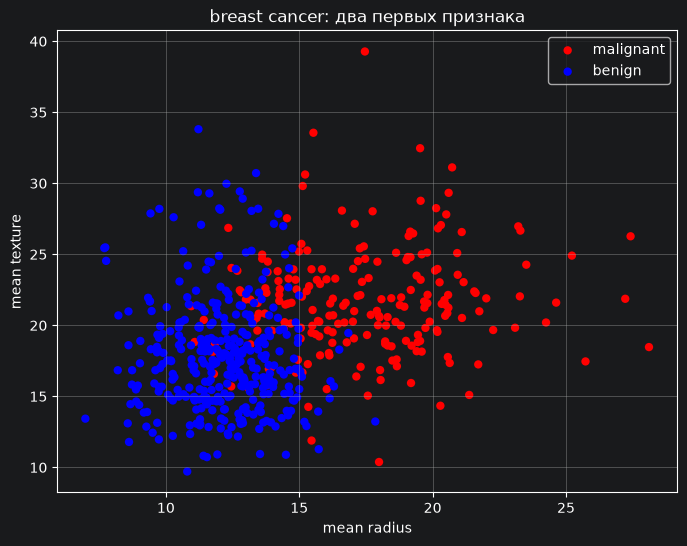

In [6]:
plt.figure(figsize=(8, 6))
for c, color in zip([0, 1], ["red", "blue"]):
    plt.scatter(X[y == c, 0], X[y == c, 1], c=color, label=cancer.target_names[c], edgecolors="none")

plt.xlabel(cancer.feature_names[0])
plt.ylabel(cancer.feature_names[1])
plt.title("breast cancer: два первых признака")
plt.legend()
plt.grid(True)
plt.show()

Классы разделяются в основном по радиусу: злокачественные опухоли крупнее. Текстура у обоих классов
перекрывается почти целиком, поэтому она добавляет мало. Между радиусом 13 и 17 идет широкая зона, где точки
двух цветов перемешаны — там и будут все ошибки.

### Шаг 3. Делим выборку на обучающую и тестовую

Делим 70/30 со стратификацией, чтобы соотношение классов сохранилось. Масштабировать признаки здесь **не нужно**:
в наивном байесе каждый признак обрабатывается отдельно своим распределением, и расстояний между объектами
мы не считаем — так что общий масштаб признаков ни на что не влияет.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print("обучающая:", X_train.shape, " тестовая:", X_test.shape)

обучающая: (398, 2)  тестовая: (171, 2)


### Шаг 4. Априорные вероятности P(A)

$P(A)$ — это просто доля объектов класса в обучающей выборке.

In [8]:
priors = []
for c in [0, 1]:
    priors.append(np.mean(y_train == c))

for c in [0, 1]:
    print("P(" + cancer.target_names[c] + ") =", round(priors[c], 4))

P(malignant) = 0.3719
P(benign) = 0.6281


In [9]:
# метрики классификации, чтобы не писать их несколько раз
# положительным классом sklearn по умолчанию считает класс 1 — benign
def print_metrics(y_true, y_pred):
    print("Accuracy  =", round(accuracy_score(y_true, y_pred), 4))
    print("Precision =", round(precision_score(y_true, y_pred), 4))
    print("Recall    =", round(recall_score(y_true, y_pred), 4))
    print("F1        =", round(f1_score(y_true, y_pred), 4))

## Часть 2. Подход 1 — численное перемножение распределений

Оцениваем $P(x_1|A)$ и $P(x_2|A)$ гистограммами: разбиваем ось признака на корзины и смотрим, какая доля
объектов класса попала в каждую корзину. Потом внешним произведением двух векторов получаем двумерную матрицу
$P([x_1,x_2]|A)$ — как на рисунке из условия.

### Шаг 5. Одномерные распределения P(x1|A) и P(x2|A)

Корзины задаем один раз по всей обучающей выборке (а не отдельно по каждому классу) — иначе сетки у классов
получатся разные и матрицы будет не с чем сравнивать.

In [10]:
n_bins = 15      # число корзин гистограммы — главный гиперпараметр этого подхода

# границы корзин, общие для обоих классов, с небольшим запасом по краям
bins1 = np.linspace(X_train[:, 0].min() - 1, X_train[:, 0].max() + 1, n_bins + 1)
bins2 = np.linspace(X_train[:, 1].min() - 1, X_train[:, 1].max() + 1, n_bins + 1)

print("корзины по mean radius: ", bins1.round(2))
print("корзины по mean texture:", bins2.round(2))

корзины по mean radius:  [ 5.98  7.36  8.75 10.13 11.51 12.9  14.28 15.66 17.05 18.43 19.81 21.2
 22.58 23.96 25.35 26.73]
корзины по mean texture: [ 8.71 10.81 12.92 15.02 17.13 19.23 21.34 23.44 25.55 27.65 29.76 31.86
 33.97 36.07 38.18 40.28]


In [11]:
# для каждого класса считаем гистограммы по каждому признаку и нормируем их на сумму,
# чтобы получились вероятности P(x1|A) и P(x2|A)
p_x1 = {}
p_x2 = {}

for c in [0, 1]:
    Xc = X_train[y_train == c]
    h1, _ = np.histogram(Xc[:, 0], bins=bins1)
    h2, _ = np.histogram(Xc[:, 1], bins=bins2)
    p_x1[c] = h1 / h1.sum()
    p_x2[c] = h2 / h2.sum()

    print(cancer.target_names[c], "— объектов:", len(Xc), " сумма P(x1|A) =", p_x1[c].sum())

malignant — объектов: 148  сумма P(x1|A) = 1.0
benign — объектов: 250  сумма P(x1|A) = 1.0


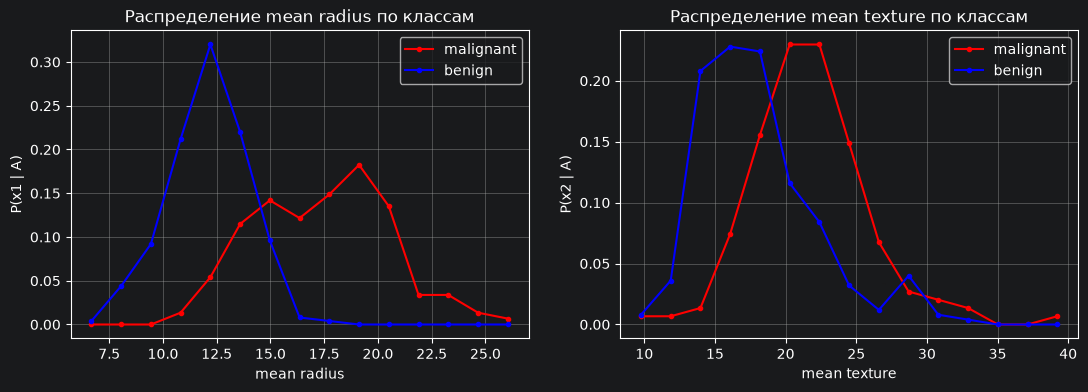

In [12]:
centers1 = (bins1[:-1] + bins1[1:]) / 2      # центры корзин, чтобы рисовать
centers2 = (bins2[:-1] + bins2[1:]) / 2

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

for c, color in zip([0, 1], ["red", "blue"]):
    ax[0].plot(centers1, p_x1[c], marker=".", color=color, label=cancer.target_names[c])
    ax[1].plot(centers2, p_x2[c], marker=".", color=color, label=cancer.target_names[c])

ax[0].set_xlabel(cancer.feature_names[0])
ax[0].set_ylabel("P(x1 | A)")
ax[0].set_title("Распределение mean radius по классам")
ax[0].legend()
ax[0].grid(True)

ax[1].set_xlabel(cancer.feature_names[1])
ax[1].set_ylabel("P(x2 | A)")
ax[1].set_title("Распределение mean texture по классам")
ax[1].legend()
ax[1].grid(True)

plt.show()

По радиусу распределения классов почти не пересекаются: у доброкачественных пик около 12, у злокачественных —
около 18. По текстуре пики стоят близко (18 и 21) и кривые накладываются друг на друга. Видно и главную
проблему гистограмм: кривые ломаные, местами провалы до нуля — там, где в обучающей выборке просто не оказалось
объектов.

### Шаг 6. Внешнее произведение: получаем двумерную матрицу P([x1, x2] | A)

Перемножаем вектор $P(x_1|A)$ длины 15 на вектор $P(x_2|A)$ длины 15 через `np.outer` и получаем матрицу
15x15 — вероятность попасть в каждую ячейку сетки.

In [13]:
p_joint = {}
for c in [0, 1]:
    p_joint[c] = np.outer(p_x1[c], p_x2[c])
    print(cancer.target_names[c], "— матрица", p_joint[c].shape, " сумма =", round(p_joint[c].sum(), 6))

malignant — матрица (15, 15)  сумма = 1.0
benign — матрица (15, 15)  сумма = 1.0


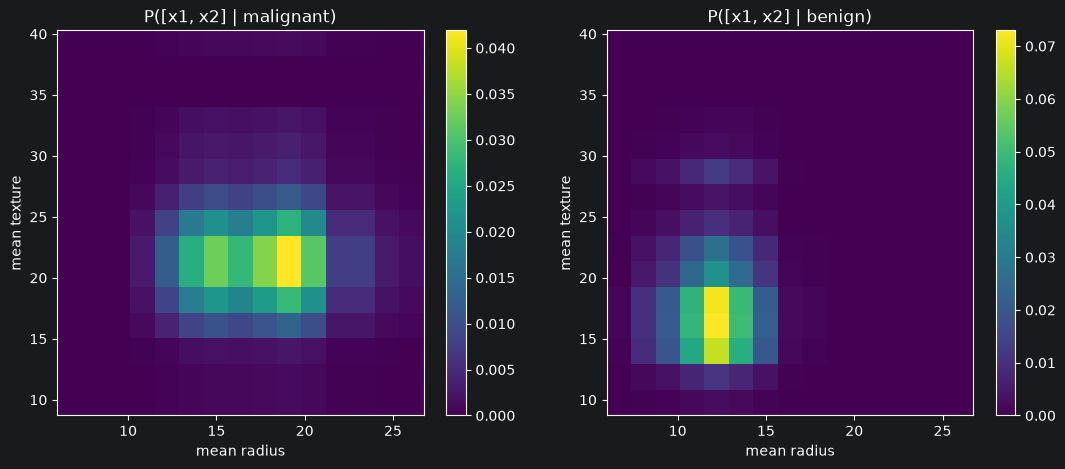

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

for c in [0, 1]:
    # матрицу транспонируем, чтобы первый признак был по горизонтали
    im = ax[c].imshow(p_joint[c].T, origin="lower", aspect="auto", cmap="viridis",
                      extent=[bins1[0], bins1[-1], bins2[0], bins2[-1]])
    ax[c].set_xlabel(cancer.feature_names[0])
    ax[c].set_ylabel(cancer.feature_names[1])
    ax[c].set_title("P([x1, x2] | " + cancer.target_names[c] + ")")
    plt.colorbar(im, ax=ax[c])

plt.show()

Получились два "холма" из ячеек, как на рисунке в условии. Холм злокачественных стоит правее (радиус 15-21) и
выше по текстуре, холм доброкачественных — левее и уже (радиус 11-14). Пересекаются они слабо, поэтому
классификация по двум признакам вообще работает. По краям матриц много нулевых ячеек — это те самые "дырки"
в данных.

### Шаг 7. Классификация: смотрим, в какую ячейку попал объект

Для нового объекта определяем номера корзин по обоим признакам (`np.digitize`), берем из матрицы каждого класса
значение этой ячейки, умножаем на $P(A)$ и выбираем класс с максимумом.

In [15]:
def predict_hist(X_new, p_joint, priors, bins1, bins2):
    y_pred = []

    for x in X_new:
        # в какую корзину попал объект по каждому признаку
        i = np.digitize(x[0], bins1) - 1
        j = np.digitize(x[1], bins2) - 1
        # если объект вылез за границы сетки, прижимаем его к крайней корзине
        i = np.clip(i, 0, len(bins1) - 2)
        j = np.clip(j, 0, len(bins2) - 2)

        # P(A|X) ~ P(X|A) * P(A) для каждого класса
        post = []
        for c in [0, 1]:
            post.append(p_joint[c][i, j] * priors[c])

        y_pred.append(np.argmax(post))

    return np.array(y_pred)

In [16]:
pred_hist = predict_hist(X_test, p_joint, priors, bins1, bins2)

pd.DataFrame({
    "mean radius": X_test[:10, 0],
    "mean texture": X_test[:10, 1],
    "правильный ответ": [cancer.target_names[i] for i in y_test][:10],
    "прогноз": [cancer.target_names[i] for i in pred_hist][:10],
})

,mean radius,mean texture,правильный ответ,прогноз
0,13.730,22.61,malignant,benign
1,13.000,20.78,benign,benign
2,11.890,17.36,benign,benign
3,19.100,26.29,malignant,malignant
4,14.480,21.46,malignant,malignant
5,15.460,23.95,malignant,malignant
6,9.738,11.97,benign,benign
7,14.450,20.22,malignant,malignant
8,12.950,16.02,benign,benign
9,24.250,20.20,malignant,malignant


### Шаг 8. Метрики и матрица ошибок (подход 1)

In [17]:
print("--- подход 1: численные распределения, корзин =", n_bins, "---")
print_metrics(y_test, pred_hist)

--- подход 1: численные распределения, корзин = 15 ---
Accuracy  = 0.8947
Precision = 0.9009
Recall    = 0.9346
F1        = 0.9174


In [18]:
cm_hist = confusion_matrix(y_test, pred_hist)
pd.DataFrame(cm_hist, index=cancer.target_names, columns=cancer.target_names)

,malignant,benign
malignant,53,11
benign,7,100


Accuracy = 0.895, F1 = 0.917. Ошибок 18 из 171, и они обоих типов: 11 злокачественных опухолей приняты за
доброкачественные и 7 доброкачественных — за злокачественные. Первый тип ошибки в медицинской задаче
опаснее: recall по классу malignant всего 53/64 = 0.83.

### Шаг 9. Карта границы классификации (подход 1)

Покрываем плоскость двух признаков сеткой точек, прогоняем каждую через свой классификатор и красим фон
в цвет предсказанного класса.

In [19]:
step = 0.1
xx, yy = np.meshgrid(np.arange(X[:, 0].min() - 1, X[:, 0].max() + 1, step),
                     np.arange(X[:, 1].min() - 1, X[:, 1].max() + 1, step))
grid = np.c_[xx.ravel(), yy.ravel()]

zz_hist = predict_hist(grid, p_joint, priors, bins1, bins2).reshape(xx.shape)

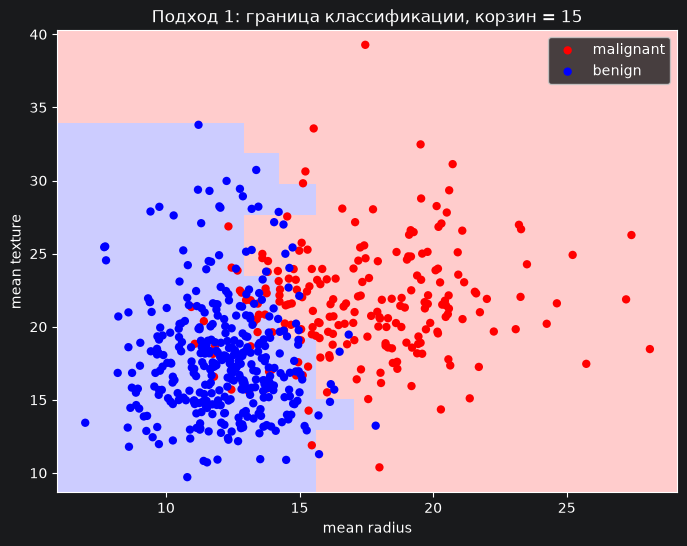

In [20]:
plt.figure(figsize=(8, 6))
plt.pcolormesh(xx, yy, zz_hist, cmap=ListedColormap(["#ffcccc", "#ccccff"]), shading="auto")

for c, color in zip([0, 1], ["red", "blue"]):
    plt.scatter(X[y == c, 0], X[y == c, 1], c=color, label=cancer.target_names[c], edgecolors="none")

plt.xlabel(cancer.feature_names[0])
plt.ylabel(cancer.feature_names[1])
plt.title("Подход 1: граница классификации, корзин = " + str(n_bins))
plt.legend()
plt.show()

Граница получилась ступенчатой — она идет по границам корзин гистограммы, мельче сетки она быть не может.
Проходит примерно по радиусу 15, что согласуется с картинкой из шага 2. Обратите внимание на края: в левом
нижнем и правом верхнем углах фон красный не потому, что там злокачественные опухоли, а потому что там у обоих
классов вероятность равна нулю (пустые ячейки), и `argmax` при равенстве отдает ответ первому классу.

### Шаг 10. Как результат зависит от числа корзин

Число корзин — единственный гиперпараметр этого подхода, посмотрим на accuracy при разных значениях.
Заодно посчитаем, сколько тестовых объектов попадает в "дырки" — ячейки, где у обоих классов вероятность нулевая.

In [21]:
bin_list = [5, 8, 10, 12, 15, 20, 25, 30, 40, 50, 80]
acc_by_bins = []
holes_by_bins = []

for nb in bin_list:
    b1 = np.linspace(X_train[:, 0].min() - 1, X_train[:, 0].max() + 1, nb + 1)
    b2 = np.linspace(X_train[:, 1].min() - 1, X_train[:, 1].max() + 1, nb + 1)

    pj = {}
    for c in [0, 1]:
        Xc = X_train[y_train == c]
        h1, _ = np.histogram(Xc[:, 0], bins=b1)
        h2, _ = np.histogram(Xc[:, 1], bins=b2)
        pj[c] = np.outer(h1 / h1.sum(), h2 / h2.sum())

    acc_by_bins.append(accuracy_score(y_test, predict_hist(X_test, pj, priors, b1, b2)))

    # считаем объекты, для которых оба класса дали нулевую вероятность
    holes = 0
    for x in X_test:
        i = np.clip(np.digitize(x[0], b1) - 1, 0, nb - 1)
        j = np.clip(np.digitize(x[1], b2) - 1, 0, nb - 1)
        if pj[0][i, j] == 0 and pj[1][i, j] == 0:
            holes += 1
    holes_by_bins.append(holes)

pd.DataFrame({"корзин": bin_list,
              "accuracy": np.round(acc_by_bins, 4),
              "объектов в пустых ячейках": holes_by_bins})

,корзин,accuracy,объектов в пустых ячейках
0,5,0.8772,0
1,8,0.9064,0
2,10,0.8947,0
3,12,0.9123,0
4,15,0.8947,0
5,20,0.8947,0
6,25,0.8889,3
7,30,0.8830,5
8,40,0.9006,4
9,50,0.8713,8


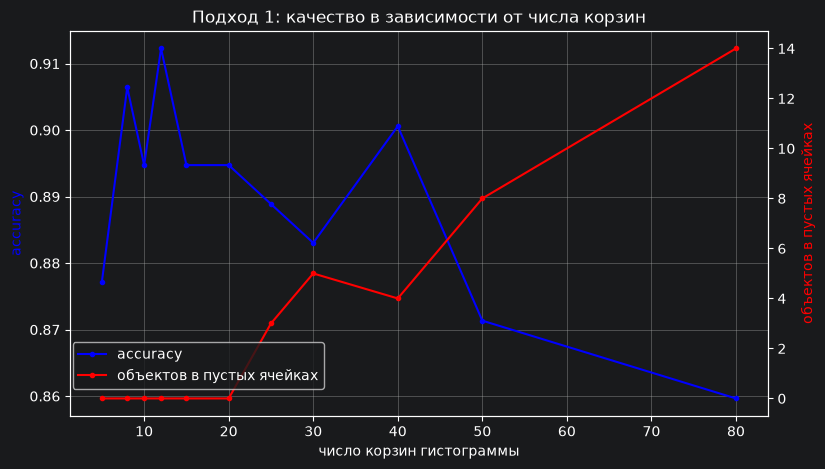

In [22]:
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(bin_list, acc_by_bins, marker=".", color="blue", label="accuracy")
ax1.set_xlabel("число корзин гистограммы")
ax1.set_ylabel("accuracy", color="blue")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(bin_list, holes_by_bins, marker=".", color="red", label="объектов в пустых ячейках")
ax2.set_ylabel("объектов в пустых ячейках", color="red")

plt.title("Подход 1: качество в зависимости от числа корзин")
fig.legend(loc="lower left", bbox_to_anchor=(0.12, 0.15))
plt.show()

Явного оптимума нет: accuracy скачет в коридоре 0.86-0.91 без понятной закономерности — это шум от того,
куда именно попали границы корзин. Зато хорошо видна вторая кривая: начиная с 25 корзин появляются тестовые
объекты, для которых оба класса дают нулевую вероятность, и к 80 корзинам их уже 14. Корзин становится
слишком много, объектов на каждую не хватает, гистограмма превращается в решето — accuracy падает до 0.86.
Слишком мало корзин (5) тоже плохо: распределение получается грубым и точность 0.877.

## Часть 3. Подход 2 — аналитические гауссовские функции

Вместо гистограммы аппроксимируем каждое одномерное распределение нормальной функцией из условия:

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \, e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

где $\mu$ — среднее признака внутри класса, $\sigma$ — его стандартное отклонение. Тогда двумерное
распределение получается сразу формулой, без всякой сетки:
$P([x_1,x_2]|A) = f(x_1) \cdot f(x_2)$.

### Шаг 11. Функция Гаусса и ее параметры по классам

In [23]:
# формула Гаусса из условия
def gauss(x, mu, sigma):
    return 1 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-(x - mu) ** 2 / (2 * sigma ** 2))

In [24]:
# для каждого класса считаем mean и std по каждому признаку — только по обучающей выборке
mu = {}
sigma = {}

for c in [0, 1]:
    Xc = X_train[y_train == c]
    mu[c] = Xc.mean(axis=0)
    sigma[c] = Xc.std(axis=0)

pd.DataFrame({
    "класс": [cancer.target_names[0], cancer.target_names[1]],
    "mu(radius)": [mu[0][0].round(3), mu[1][0].round(3)],
    "sigma(radius)": [sigma[0][0].round(3), sigma[1][0].round(3)],
    "mu(texture)": [mu[0][1].round(3), mu[1][1].round(3)],
    "sigma(texture)": [sigma[0][1].round(3), sigma[1][1].round(3)],
})

,класс,mu(radius),sigma(radius),mu(texture),sigma(texture)
0,malignant,17.448,3.092,21.647,4.056
1,benign,12.108,1.754,17.976,4.173


### Шаг 12. Насколько хорошо гауссиана описывает реальные данные

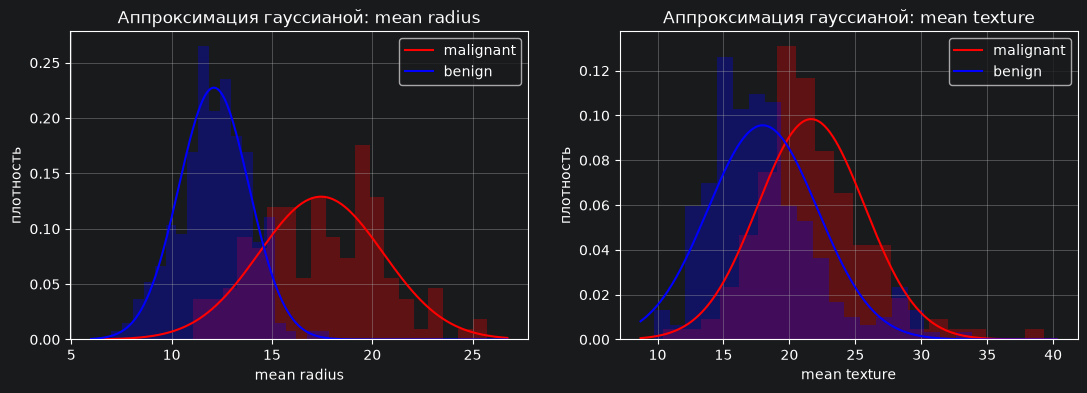

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

for f in [0, 1]:
    grid_f = np.linspace(X_train[:, f].min() - 1, X_train[:, f].max() + 1, 300)
    for c, color in zip([0, 1], ["red", "blue"]):
        # гистограмма реальных данных и поверх нее аппроксимация
        ax[f].hist(X_train[y_train == c][:, f], bins=20, density=True, alpha=0.3, color=color)
        ax[f].plot(grid_f, gauss(grid_f, mu[c][f], sigma[c][f]), color=color,
                   label=cancer.target_names[c])

    ax[f].set_xlabel(cancer.feature_names[f])
    ax[f].set_ylabel("плотность")
    ax[f].set_title("Аппроксимация гауссианой: " + cancer.feature_names[f])
    ax[f].legend()
    ax[f].grid(True)

plt.show()

Аппроксимация в целом попадает в данные, но не идеально: оба признака скошены вправо (длинный хвост в сторону
больших значений), а гауссиана симметрична. Сильнее всего расходится `mean radius` у злокачественных — реальная
гистограмма там двугорбая, а гауссиана рисует один широкий симметричный холм.

### Шаг 13. Двумерное распределение как произведение двух гауссиан

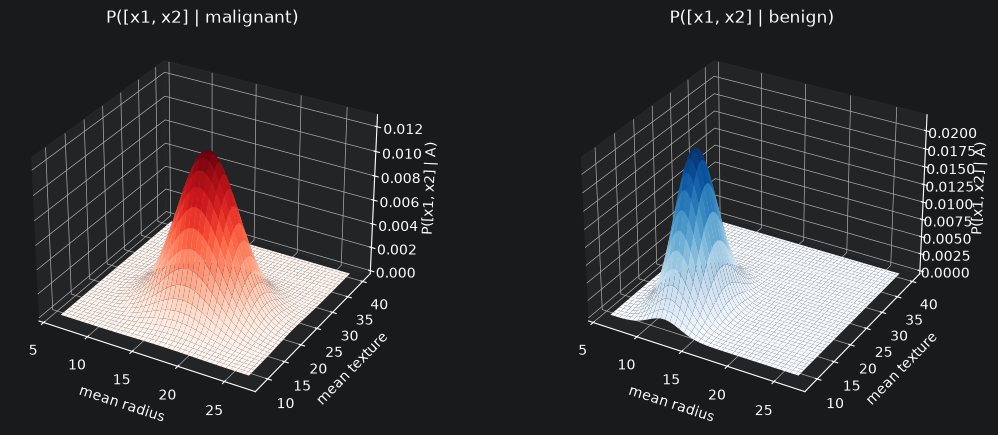

In [26]:
g1 = np.linspace(bins1[0], bins1[-1], 120)
g2 = np.linspace(bins2[0], bins2[-1], 120)
G1, G2 = np.meshgrid(g1, g2)

fig = plt.figure(figsize=(13, 5))
for c, cmap in zip([0, 1], ["Reds", "Blues"]):
    Z = gauss(G1, mu[c][0], sigma[c][0]) * gauss(G2, mu[c][1], sigma[c][1])

    ax = fig.add_subplot(1, 2, c + 1, projection="3d")
    ax.plot_surface(G1, G2, Z, cmap=cmap)
    ax.set_xlabel(cancer.feature_names[0])
    ax.set_ylabel(cancer.feature_names[1])
    ax.set_zlabel("P([x1, x2] | A)")
    ax.set_title("P([x1, x2] | " + cancer.target_names[c] + ")")

plt.show()

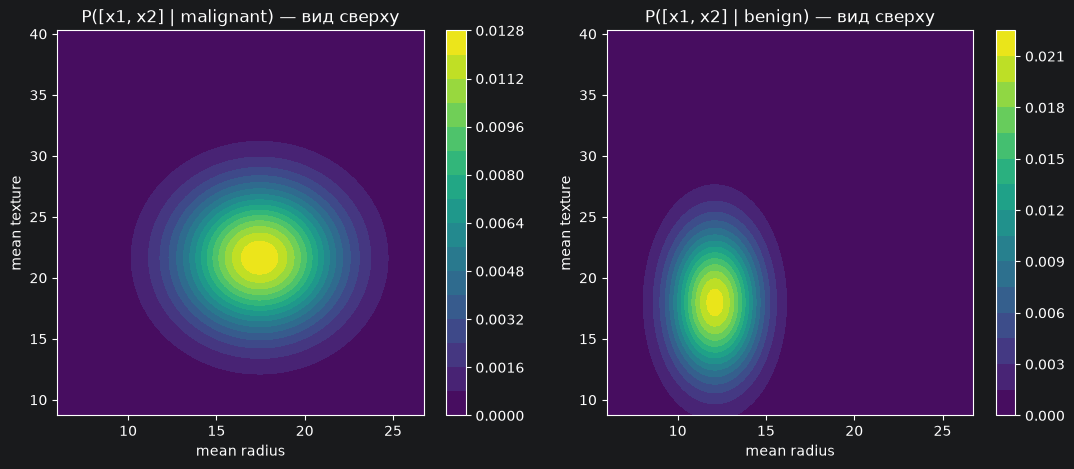

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

for c in [0, 1]:
    Z = gauss(G1, mu[c][0], sigma[c][0]) * gauss(G2, mu[c][1], sigma[c][1])
    im = ax[c].contourf(G1, G2, Z, levels=20, cmap="viridis")
    ax[c].set_xlabel(cancer.feature_names[0])
    ax[c].set_ylabel(cancer.feature_names[1])
    ax[c].set_title("P([x1, x2] | " + cancer.target_names[c] + ") — вид сверху")
    plt.colorbar(im, ax=ax[c])

plt.show()

Те же два холма, что и в подходе 1, только теперь гладкие и заданные формулой. Линии уровня — эллипсы с осями
вдоль признаков: это прямое следствие "наивного" предположения о независимости, при котором наклонных эллипсов
получиться не может. Холм доброкачественных заметно уже по радиусу (sigma = 1.75 против 3.09) и потому выше.

### Шаг 14. Классификация, метрики и матрица ошибок (подход 2)

In [28]:
def predict_gauss(X_new, mu, sigma, priors):
    y_pred = []

    for x in X_new:
        post = []
        for c in [0, 1]:
            # P([x1,x2]|A) = f(x1) * f(x2), дальше умножаем на P(A)
            p = gauss(x[0], mu[c][0], sigma[c][0]) * gauss(x[1], mu[c][1], sigma[c][1])
            post.append(p * priors[c])

        y_pred.append(np.argmax(post))

    return np.array(y_pred)

In [29]:
pred_gauss = predict_gauss(X_test, mu, sigma, priors)

print("--- подход 2: аналитические гауссианы ---")
print_metrics(y_test, pred_gauss)

--- подход 2: аналитические гауссианы ---
Accuracy  = 0.8772
Precision = 0.8707
Recall    = 0.9439
F1        = 0.9058


In [30]:
cm_gauss = confusion_matrix(y_test, pred_gauss)
pd.DataFrame(cm_gauss, index=cancer.target_names, columns=cancer.target_names)

,malignant,benign
malignant,49,15
benign,6,101


Accuracy = 0.877, F1 = 0.906 — чуть хуже, чем у гистограммного подхода. Ошибок 21: 15 злокачественных приняты
за доброкачественные и 6 наоборот. То есть гладкая модель немного сильнее перетягивает спорную зону в сторону
доброкачественных (их априорная вероятность выше), зато ошибок второго типа делает меньше.

### Шаг 15. Карта границы классификации (подход 2)

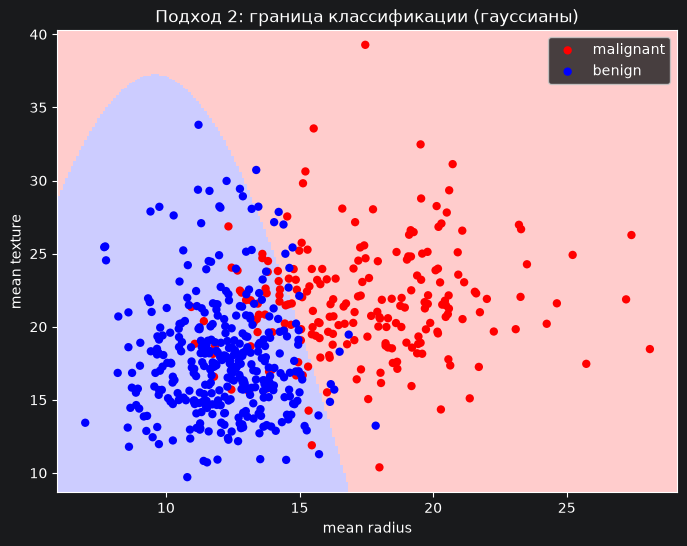

In [31]:
zz_gauss = predict_gauss(grid, mu, sigma, priors).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.pcolormesh(xx, yy, zz_gauss, cmap=ListedColormap(["#ffcccc", "#ccccff"]), shading="auto")

for c, color in zip([0, 1], ["red", "blue"]):
    plt.scatter(X[y == c, 0], X[y == c, 1], c=color, label=cancer.target_names[c], edgecolors="none")

plt.xlabel(cancer.feature_names[0])
plt.ylabel(cancer.feature_names[1])
plt.title("Подход 2: граница классификации (гауссианы)")
plt.legend()
plt.show()

Граница гладкая и выпуклая — это кривая второго порядка, никаких ступенек нет. Область доброкачественных
выглядит как купол: при радиусе меньше 15 объект относится к benign, но чем дальше текстура от своего среднего
(18), тем этот порог по радиусу строже. Никаких "паразитных" красных углов, как в подходе 1, здесь не
появляется: гауссиана нигде не обращается в ноль, поэтому argmax всегда сравнивает осмысленные числа.

## Часть 4. Сравнение подходов

### Шаг 16. Сверяем подход 2 с готовым GaussianNB

`GaussianNB` из sklearn делает ровно то же, что наш подход 2, — значит прогнозы должны совпасть.

In [32]:
nb_sklearn = GaussianNB()
nb_sklearn.fit(X_train, y_train)
pred_sklearn = nb_sklearn.predict(X_test)

print("--- sklearn GaussianNB ---")
print_metrics(y_test, pred_sklearn)
print()
print("прогнозы совпадают со своей реализацией:", np.array_equal(pred_gauss, pred_sklearn))

--- sklearn GaussianNB ---
Accuracy  = 0.8772
Precision = 0.8707
Recall    = 0.9439
F1        = 0.9058

прогнозы совпадают со своей реализацией: True


In [33]:
# сверим и сами параметры распределений
print("свои mu:\n", np.array([mu[0], mu[1]]).round(4))
print("mu sklearn:\n", nb_sklearn.theta_.round(4))
print()
print("свои sigma:\n", np.array([sigma[0], sigma[1]]).round(4))
print("sigma sklearn:\n", np.sqrt(nb_sklearn.var_).round(4))

свои mu:
 [[17.4478 21.6474]
 [12.1083 17.9765]]
mu sklearn:
 [[17.4478 21.6474]
 [12.1083 17.9765]]

свои sigma:
 [[3.0921 4.0556]
 [1.7537 4.1732]]
sigma sklearn:
 [[3.0921 4.0556]
 [1.7537 4.1732]]


Прогнозы совпали объект в объект, и параметры $\mu$, $\sigma$ у нас и у sklearn одинаковые до четвертого знака —
значит аналитический подход написан правильно.

### Шаг 17. Итоговая таблица

In [34]:
results = pd.DataFrame({
    "подход": ["1. численно (гистограммы)", "2. аналитически (гауссианы)", "sklearn GaussianNB"],
    "Accuracy": [accuracy_score(y_test, p) for p in [pred_hist, pred_gauss, pred_sklearn]],
    "Precision": [precision_score(y_test, p) for p in [pred_hist, pred_gauss, pred_sklearn]],
    "Recall": [recall_score(y_test, p) for p in [pred_hist, pred_gauss, pred_sklearn]],
    "F1": [f1_score(y_test, p) for p in [pred_hist, pred_gauss, pred_sklearn]],
}).round(4)

results

,подход,Accuracy,Precision,Recall,F1
0,1. численно (гистограммы),0.8947,0.9009,0.9346,0.9174
1,2. аналитически (гауссианы),0.8772,0.8707,0.9439,0.9058
2,sklearn GaussianNB,0.8772,0.8707,0.9439,0.9058


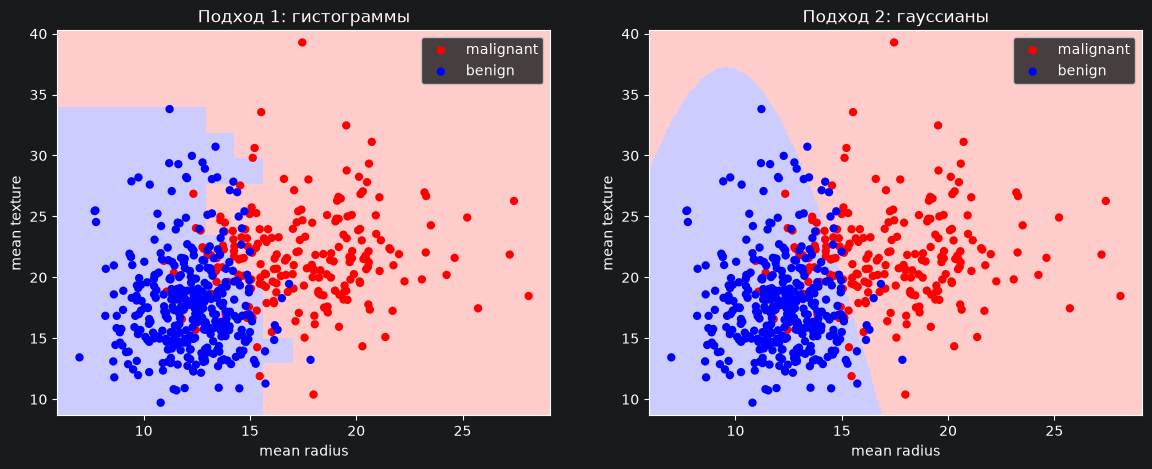

In [35]:
# две границы рядом, чтобы разница была видна глазами
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for k, (zz_k, name) in enumerate([(zz_hist, "Подход 1: гистограммы"),
                                  (zz_gauss, "Подход 2: гауссианы")]):
    ax[k].pcolormesh(xx, yy, zz_k, cmap=ListedColormap(["#ffcccc", "#ccccff"]), shading="auto")
    for c, color in zip([0, 1], ["red", "blue"]):
        ax[k].scatter(X[y == c, 0], X[y == c, 1], c=color, label=cancer.target_names[c],
                      edgecolors="none")
    ax[k].set_xlabel(cancer.feature_names[0])
    ax[k].set_ylabel(cancer.feature_names[1])
    ax[k].set_title(name)
    ax[k].legend()

plt.show()

**Общий вывод.** Оба подхода — это один и тот же наивный байесовский классификатор
$P(A|X) \propto P(x_1|A) \cdot P(x_2|A) \cdot P(A)$, отличаются они только тем, как оценивается одномерное
распределение признака внутри класса. По качеству на двух признаках они почти равны: 0.895 у численного против
0.877 у аналитического, разница в три-четыре объекта из 171 и на другом разбиении легко поменяет знак.

**Численный подход** ничего не предполагает о форме распределения — он берет ее прямо из данных, поэтому
справляется и с несимметричными, и с двугорбыми признаками (`mean radius` у злокачественных как раз такой).
Но за это приходится платить:
- результат зависит от числа корзин, и оптимум приходится подбирать вслепую — accuracy скачет в коридоре
  0.86-0.91 без внятной закономерности;
- в матрице появляются **"дырки"** — ячейки, где у обоих классов вероятность нулевая. При 15 корзинах их
  33 из 225, при 80 корзинах — больше половины, и в них уже попадают реальные тестовые объекты (14 штук),
  для которых классификатор не может сказать ничего осмысленного и по факту отвечает наугад;
- границы классификации ступенчатые, мельче корзины они быть не могут;
- памяти нужно $bins^2$ на класс, и с ростом числа признаков это растет как $bins^{n}$ — именно поэтому
  в условии сказано брать всего два признака.

**Аналитический подход** хранит на класс всего 4 числа ($\mu$ и $\sigma$ по каждому признаку), считается
мгновенно, дает гладкую границу и нигде не обращается в ноль, так что проблемы "дырок" у него нет вообще.
Но он верен только пока признаки похожи на нормальные: на графике шага 12 видно, что оба признака скошены
вправо, и симметричная гауссиана этот перекос не воспроизводит. Если бы признак был, например, явно
двугорбым или категориальным, аналитический подход просто дал бы неправильное распределение, а численный
все равно бы сработал.

Совпадение нашего аналитического подхода с `GaussianNB` объект в объект подтверждает, что метод реализован
правильно. По самой задаче: на двух признаках наивный байес дает accuracy около 0.88-0.90, и обе модели
чаще всего ошибаются одинаково — принимают злокачественную опухоль за доброкачественную в зоне перекрытия
классов (радиус 13-17). В медицинской задаче это самая неприятная ошибка, так что здесь стоит смотреть
не на accuracy, а на recall по классу malignant — он всего 0.77-0.83.